# Models discussed in this worksheet! 

- Neural Network
- Deep learning Neural Networks

## Model building approach for this worksheet!

- Import the libraries. For example: import numpy as np
- Define/create input data. For example, use numpy to create a dataset and an array of data values.
- Add weights and bias (if applicable) to input features. These are learnable parameters, meaning that they can be adjusted during training.
    - Weights = input parameters that influences output
    - Bias = an extra threshold value added to the outpu
- Train the network against known, good data in order to find the correct values for the weights and biases.
- Test the Network against a set of test data to see how it performs. 
- Fit the model with hyperparameters (parameters whose values are used to control the learning process), calculate accuracy, and make a prediction.
- Visualization

</div>

# Loading the packages
__Note__: While packages are loading you can proceed with working on the worksheet. if tensorflow and keras are not installed, please use `!pip install tensorflow`. It also might need `pip install pydot graphviz`

In [83]:
import numpy as np
import pandas as pd
np.random.seed(42)  # for reproducibility
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import SVG
# from scipy.misc import imread, imresize

from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten,GlobalAveragePooling2D, Input, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D
from keras.layers import Convolution2D, MaxPooling2D, AveragePooling2D, GlobalMaxPooling2D, GlobalAveragePooling2D
from keras.utils import to_categorical
from keras.datasets import mnist
from tensorflow.keras.utils import plot_model, model_to_dot
from tensorflow.keras.utils import plot_model


## Neural Network and Deep Learning

- Let us move to the artificial neural network (ANN) without going into the intricacies of how a biological brain works.
- An ANN model is a two-stage regression or classification model.
- It can handle multiple quantitative responses seamlessly.
- It can model highly complex relationships between inputs and response variables, both linear and non-linear. 
- It requires no underlying assumptions to create and evaluate the model.

Figure 1 presents a simple network, the inputs or covariates consist of two nodes or neurons:
- The neuron labeled 1 represents a constant or more appropriately, the intercept.
- Here, 
    - `X1` represents a quantitative variable. 
    - The `Ws` represent the weights that are multiplied by the input node values. These values become input nodes to a hidden node. 
    - You can have multiple hidden nodes. At `H1` hidden node, the weight * value computations are summed up.
    - After that the summed value is then transformed with the activation function, turning the input signal to an output signal. 
- Figure 1 has only one hidden node and is multiplied by `W3` and becomes the estimate of `Y`, our response. 
- This is the feed-forward portion of the algorithm.

![Feed-forward neural network](images/ANN.PNG)

Figure 2 presents the back-propagation in a neural network:
- It trains back the model that has been learned so far.
- Error is calculated based on the loss function (e.g. sum of square error).
- Working backward the weights are changed to minimize the error of the loss function. 

<img src="https://github.com/sukhjitsehra/datasets/blob/master/ST494/images/BP.png?raw=true" width="800">

 | Fig 2: Backpropagation in neural network |
| --- |

## Building Basic Neural Network Model

In [34]:
class NeuralNetwork():
    
    def __init__(self, no_of_input_nodes, no_of_hidden_nodes, output_size):
        self.no_of_input_nodes = no_of_input_nodes
        self.no_of_hidden_nodes = no_of_hidden_nodes
        self.output_size = output_size
        
        # Initialize weights and biases randomly
        self.weights1 = np.random.randn(self.no_of_input_nodes, self.no_of_hidden_nodes)
        self.bias1 = np.random.randn(self.no_of_hidden_nodes)
        self.weights2 = np.random.randn(self.no_of_hidden_nodes, self.output_size)
        self.bias2 = np.random.randn(self.output_size)
        
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_derivative(self, x):
        return x * (1 - x)
    
    def forward(self, X):
        # Calculate the output of the first layer
        self.layer1 = self.sigmoid(np.dot(X, self.weights1) + self.bias1)
        # Calculate the output of the second layer
        self.output = self.sigmoid(np.dot(self.layer1, self.weights2) + self.bias2)
        return self.output
    
    def backward(self, X, y, learning_rate):
        # Calculate the error of the output layer
        output_error = y - self.output
        # Calculate the derivative of the sigmoid function
        output_derivative = self.sigmoid_derivative(self.output)
        # Calculate the error of the hidden layer
        hidden_error = np.dot(output_error * output_derivative, self.weights2.T)
        # Calculate the derivative of the sigmoid function
        hidden_derivative = self.sigmoid_derivative(self.layer1)
        # Update the weights and biases of the second layer
        self.weights2 += learning_rate * np.dot(self.layer1.T, output_error * output_derivative)
        self.bias2 += learning_rate * np.sum(output_error * output_derivative, axis=0)
        # Update the weights and biases of the first layer
        self.weights1 += learning_rate * np.dot(X.T, hidden_error * hidden_derivative)
        self.bias1 += learning_rate * np.sum(hidden_error * hidden_derivative, axis=0)
        
    def train(self, X, y, epochs, learning_rate):
        self.loss = []
        for i in range(epochs):
            output = self.forward(X)
            self.backward(X, y, learning_rate)
            # Calculate the mean squared error and append it to the loss list
            mse = np.mean((y - output) ** 2)
            self.loss.append(mse)
        # Plot the loss over the epochs
        plt.plot(self.loss)
        plt.xlabel('Epoch')
        plt.ylabel('Mean Squared Error')
        plt.show()
        
    def predict(self, X):
        return self.forward(X)
    
    def plot_nn(self):
        # Create a new figure
        fig, ax = plt.subplots()
        # Plot the input layer
        ax.scatter(np.zeros(self.no_of_input_nodes), np.arange(self.no_of_input_nodes), s=500, color='white', edgecolor='black')
        # Plot the hidden layer
        ax.scatter(np.ones(self.no_of_hidden_nodes), np.arange(self.no_of_hidden_nodes), s=500, color='white', edgecolor='black')
        # Plot the output layer
        ax.scatter(2 * np.ones(self.output_size), np.arange(self.output_size), s=500, color='white', edgecolor='black')
        # Connect the nodes with lines representing the weights
        for i in range(self.no_of_input_nodes):
            for j in range(self.no_of_hidden_nodes):
                ax.plot([0, 1], [i, j], color='black', linewidth=self.weights1[i, j])
        for i in range(self.no_of_hidden_nodes):
            for j in range(self.output_size):
                ax.plot([1, 2], [i, j], color='black', linewidth=self.weights2[i, j])
        # Set the axis limits and labels
        ax.set_xlim([-0.5, 2.5])
        ax.set_ylim([-0.5, max(self.no_of_input_nodes, self.no_of_hidden_nodes, self.output_size) - 0.5])
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(['Input', 'Hidden', 'Output'])
        ax.set_yticks(np.arange(max(self.no_of_input_nodes, self.no_of_hidden_nodes, self.output_size)))
        ax.set_yticklabels(np.arange(max(self.no_of_input_nodes, self.no_of_hidden_nodes, self.output_size)) + 1)
        ax.set_title('Neural Network Architecture')
        plt.show()



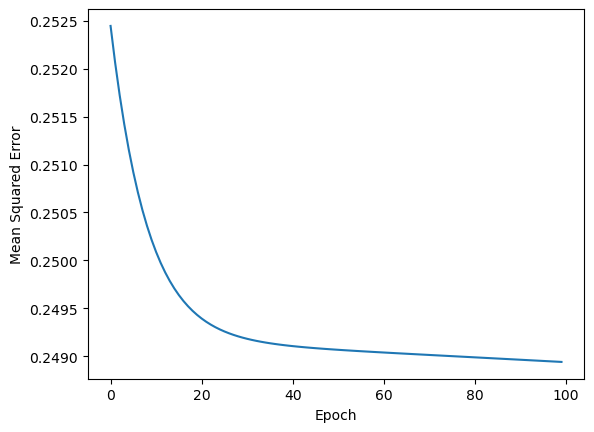

[[0.49336228]
 [0.5215972 ]
 [0.48476248]
 [0.5079407 ]]


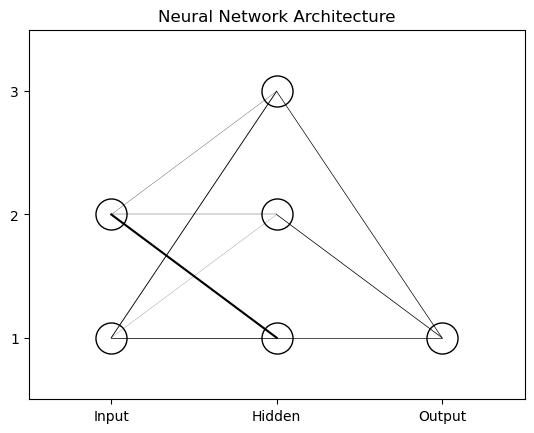

In [35]:
import numpy as np

# Define the input data and corresponding output data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Create a neural network with 2 input nodes, 4 hidden nodes, and 1 output node
nn = NeuralNetwork(2, 3, 1)

# Train the neural network for 10000 epochs with a learning rate of 0.1
nn.train(X, y, 100, 0.1)

# Use the neural network to make predictions on some new data
print(nn.predict(np.array([[0, 0], [0, 1], [1, 0], [1, 1]])))

nn.plot_nn()

## Going Deep into Deep Learning

ANNs can get much more complex than previous discussion and may include multiple hidden layers. Similar to the human brain, information flows from one layer to another irrespective of number of layers. This leads to deep learning, where  “deep” in deep learning refers to the depth of layers in a neural network.  Deep learning is effective in many areas, including robotics, image recognition, and artificial intelligence (AI). In this worksheet, we are going to use `keras` package for performing deep learning in Python. The structure of building the deep learning model is pre-processing and loading the data; defining model, tuning hyperparameters and fitting the final model, and testing the model.

Keras is a high-level neural networks API developed with a focus on enabling fast experimentation. It supports multiple backends, including TensorFlow, CNTK and Theano.

TensorFlow is a lower level mathematical library for building deep neural network architectures. The keras Python package makes it
easy to use Keras and TensorFlow in Python. The [keras Python cheatsheet](https://res.cloudinary.com/dyd911kmh/image/upload/v1660903348/Keras_Cheat_Sheet_gssmi8.pdf) may be helpful to build the models. 

Keras has the following key features:

- Allows the same code to run on CPU or on GPU, seamlessly.
- Provides a simple and consistent interface optimized for common use cases. It provides clear and actionable feedback for user errors.
- Modular and composable as models can be made by configurable blocks together with few restrictions.

- User-friendly API which makes it easy to quickly prototype deep learning models.

- Built-in support for convolutional networks (for computer vision), recurrent networks (for sequence processing), and any combination of both.

- Supports arbitrary network architectures: multi-input or multi-output models, layer sharing, model sharing, etc. This means that Keras is appropriate for building essentially any deep learning model, from a memory network to a neural Turing machine.

Keras models are divided into two parts:


- Keras Sequential API: It allows us to develop models in a layer-by-layer fashion. However, we cannot create models with numerous inputs and outputs with it. For simple layer stacks with only one input and output tensor, it works well.
- Keras functional API: It can be used to create models with various inputs and outputs.


Using dataset without scaling can make learning more difficult for the network, but model might be capable of adapting to such heterogeneous data. To normalize the data, for each column in the input data matrix, we subtract the mean of the feature and divide by the standard deviation, so that the feature is centered around 0 and has a unit standard deviation. 

### Sequential Model
In Keras, we assemble layers to build models. A model is (usually) a graph of layers. The most common type of model is a stack of layers: the sequential model. Let's start defining a basic fully-connected network (i.e., a multi-layer perceptron) model using sequential API, we would assemble layers to build model (a graph of layers).   

There are many layers available with some common constructor parameters:

- activation: Set the activation function for the layer. By default, no activation is applied.
- kernel_initializer and bias_initializer: The initialization schemes that create the layer’s weights (kernel and bias). This defaults to the Glorot uniform initializer.
- kernel_regularizer and bias_regularizer: The regularization schemes that apply to the layer’s weights (kernel and bias), such as L1 or L2 regularization. By default, no regularization is applied.


Naming models and layers with the name argument

In [36]:
# Import python libraries required in this example:
from keras.models import Sequential
from keras.layers import Dense, Activation
import numpy as np

# Use numpy arrays to store inputs (x) and outputs (y):
x = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]]) 

# Define the network model and its arguments. 
# Set the number of neurons/nodes for each layer:
model = Sequential()
model.add(Dense(2, input_shape=(2,)))
model.add(Activation('sigmoid'))
model.add(Dense(1))
model.add(Activation('sigmoid')) 

# Compile the model and calculate its accuracy:
model.compile(loss='mean_squared_error', optimizer='sgd', metrics=['accuracy']) 

# Print a summary of the Keras model:
model.summary()

plot_model(model, to_file='mnist_model.png')

/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


### Train and evaluate
After the model is constructed, now let's configure its learning process by calling the compile(...) method:

The compile() method takes three important arguments:

- optimizer: This object specifies the training procedure. Commonly used optimizers are e.g. adam, rmsprop, or sgd.
    - Stochastic gradient descent (SGD): This is the simplest optimizer. For every weight, the model stores an error rate. Depending on the direction of the error, whether the predicted value is greater than or less than the true value, a small learning rate is applied to the weight to change the next round of results so that the predicted values are incrementally moving in the opposite direction as the error. This process is simple, but for deep neural networks, the fine adjustments at every iteration mean that it can take a long time for the model to converge.

    - Adagrad/Adadelta: Adagrad improves on SGD through the use of a matrix of all previous errors per node rather than one error rate for all nodes; however, the use of this matrix of values means that the learning rate can be canceled out of the model runs for too long. Adadelta is the correction for the limitation of Adagrad. Adadelta uses momentum to solve the growing error rate matrix problem.
    - PythonMSprop: This is a separate correction to Adagrad. It is similar to Adadelta, however, with RMSprop, the learning rate is not only divided by a matrix of local per-node decaying average error rates, but also by a global decaying average of all squared error rates.
    - Adam: Adam includes not only an exponentially decaying average of squared error rates, as seen in RMSprop, but also an exponentially decaying average of error rates (not squared).
- loss: The function to minimize during optimization. Common choices include mean square error (mse), categorical_crossentropy, and binary_crossentropy.
    - binary_crossentropy: This loss function is used for classification problems where the requirement is to assign input data to one of two classes. This can also be used when assigning input data to more than one or two classes if it is possible for a given case to belong to more than one class. In this case, each target class is treated as a separate binary class (for each target class the given case belongs to or does not belong to). This can also be used for regression when the target values are between 0 and 1.
    - categorical_crossentropy: Categorical crossentropy is used with a multinominal classification problem where any given row of input data can only belong to one of the more than two classes. As we noted with binary crossentropy, in order to use categorical crossentropy, the target vector must be converted to a matrix so that there is a value of 1 for the index associated with the target class for every given row. If the target vector contains integers that are meant to be treated as integers and not categorical classes, then sparse_categorical_crossentropy can be used without performing the matrix conversion required for categorical crossentropy. 
    - MSE (mean squared error): Mean squared error is an appropriate choice for regression problems since the predicted values and true values can be any number. This loss function takes the square of the difference between the predicted values and the target values.
- metrics: Used to monitor training. Common choices are:
    - Accuracy: This metric measures how often the correct class is predicted. By default, 0.5 is used as a threshold, which means that if the predicted probability is below 0.5, then the predicted class is 0; otherwise, it is 1. The total number of cases where the predicted class matches the target class is divided by the total number of target variables.
    - Cosine similarity: Compares the similarity between two vectors by evaluating the similarity of terms in n-dimensional space. This is used often to evaluate the similarity of text data. 
    -  Mean absolute error: The average value for all absolute errors. The absolute error is the difference between the predicted variable and the target variable.

    -  Mean squared error: The average value for all squared errors. The squared error is the square of the difference between the predicted variable and the target variable. Through squaring the errors, an increased penalty is applied to larger errors relative to mean absolute error.
    - Hinge: To use the hinge evaluation metric, all target variables should be -1 or 1. From here, the formula is to subtract the product of the predicted value and the target variable from 1 and then to use this value or 0, whichever is greater for evaluation. Results are evaluated as more correct the closer the metric value is to 0.
    - KL divergence: This metric compares the distribution of true results with the distribution of predicted results and evaluates the similarity of the distribution.


### Fitting the model

A model is fit to the training data using the fit method, which takes three important parameters into consideration:

- epochs: Training is structured into epochs. An epoch is one iteration over the entire input data (this is done in smaller batches).
- batch_size: When matrix or array data is passed as input, the model slices the data into smaller batches and iterates over these batches during training. This integer specifies the size of each batch. Be aware that the last batch may be smaller if the total number of samples is not divisible by the batch size.
- validation_data: When prototyping a model, you want to easily monitor its performance on some validation data. Passing this argument - a list of inputs and labels - allows the model to display the loss and metrics in inference mode for the passed data, at the end of each epoch.
Let's fit the model using some values, considered good to start the model fitting process:

### Evaluate and predict
Same as fit, the evaluate and predict methods can use raw R data as well as a dataset.

- evaluate: it evaluate the inference-mode loss and metrics for the data provided.
- predict: to predict the output of the last layer in inference for the data provided.

## Predicting house prices: A regression example

### The Boston Housing Price dataset

**Loading the Boston housing dataset**

In [37]:
from tensorflow.keras.datasets import boston_housing
(X_train_bos, y_train_bos), (X_test_bos, y_test_bos) = boston_housing.load_data()

In [38]:
X_train_bos.shape

(404, 13)

In [39]:
X_test_bos.shape

(102, 13)

In [40]:
y_train_bos

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

### Preparing the data

**Normalizing the data**

In [41]:
mean = X_train_bos.mean(axis=0)
X_train_bos -= mean
std = X_train_bos.std(axis=0)
X_train_bos /= std
X_test_bos -= mean
X_test_bos /= std

### Building your model

**Model definition**

In [42]:
def build_model():
    model = Sequential()
    model.add(Dense(64, activation="relu"))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(1))
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

### Validating your approach using K-fold validation

**K-fold validation**

In [43]:
k = 4
num_val_samples = len(X_train_bos) // k
num_epochs = 100
all_scores = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = X_train_bos[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = y_train_bos[i * num_val_samples: (i + 1) * num_val_samples]
    partial_X_train_bos = np.concatenate(
        [X_train_bos[:i * num_val_samples],
         X_train_bos[(i + 1) * num_val_samples:]],
        axis=0)
    partial_y_train_bos = np.concatenate(
        [y_train_bos[:i * num_val_samples],
         y_train_bos[(i + 1) * num_val_samples:]],
        axis=0)
    model = build_model()
    model.fit(partial_X_train_bos, partial_y_train_bos,
              epochs=num_epochs, batch_size=16, verbose=0)
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


In [44]:
all_scores

[1.957661509513855, 2.4967596530914307, 2.4483513832092285, 2.3361763954162598]

In [45]:
np.mean(all_scores)

np.float64(2.3097372353076935)

**Saving the validation logs at each fold**

In [46]:
num_epochs = 50
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = X_train_bos[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = y_train_bos[i * num_val_samples: (i + 1) * num_val_samples]
    partial_X_train_bos = np.concatenate(
        [X_train_bos[:i * num_val_samples],
         X_train_bos[(i + 1) * num_val_samples:]],
        axis=0)
    partial_y_train_bos = np.concatenate(
        [y_train_bos[:i * num_val_samples],
         y_train_bos[(i + 1) * num_val_samples:]],
        axis=0)
    model = build_model()
    history = model.fit(partial_X_train_bos, partial_y_train_bos,
                        validation_data=(val_data, val_targets),
                        epochs=num_epochs, batch_size=16, verbose=0)
    mae_history = history.history["val_mae"]
    all_mae_histories.append(mae_history)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


**Building the history of successive mean K-fold validation scores**

In [47]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

**Plotting validation scores**

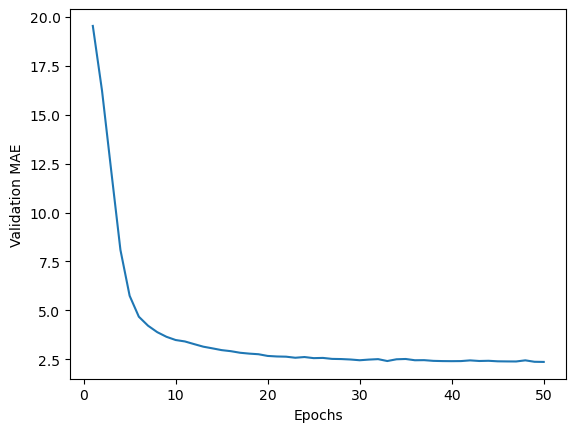

In [48]:
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

**Plotting validation scores, excluding the first 10 data points**

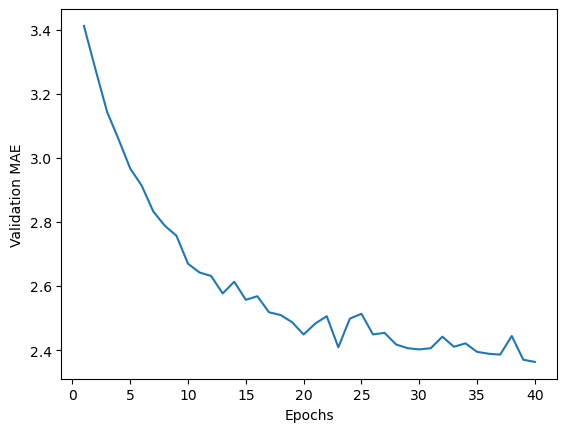

In [49]:
truncated_mae_history = average_mae_history[10:]
plt.plot(range(1, len(truncated_mae_history) + 1), truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

**Training the final model**

In [50]:
model = build_model()
model.fit(X_train_bos, y_train_bos,
          epochs=10, batch_size=16, verbose=0)
test_mse_score, test_mae_score = model.evaluate(X_test_bos, y_test_bos)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.2331 - mae: 3.4746 


In [51]:
test_mae_score

3.474565029144287

### Generating predictions on new data

In [52]:
predictions = model.predict(X_test_bos)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


array([9.810005], dtype=float32)

##  Convolutional Neural Network for Image Recognition

Let's now focus on applying convolutional neural networks (CNNs) for image recognition problem. CNNs are a variation of  neural networks that are particularly well-suited to image recognition because they take into account the
relationship between data points in space. A CNN differs from a basic feedforward network. The main difference is that hidden layers in a CNN are not all fully connected layers and also CNNs include a number of special layers. One of these is the convolutional layer, which convolves a filter around the image space. The other special layer is a pooling layer, which reduces the size of the input and only persists particular values.

- In a traditional neural network, the input is passed to the model as vectors; however, for image data, it is more helpful to have the data arranged as matrices because we want to capture the relationship of the pixel values in two-dimensional space. CNNs are able to capture these two-dimensional relationships through the use of a filter that convolves over the image data. 

- The filter is a matrix with constant values and dimensions that are smaller than the image data. The constant values are multiplied by the underlying values and the sum of the resulting products is passed through to an activation function.

- The activation function step, which can also be considered a separate layer, evaluates whether a given pattern is present in an image. In a traditional neural network, the activation layer determines whether the calculated value from the input values exceeds a threshold and should be fed forward in the model. 

- In a CNN, the activation layer operates in a very similar way; however, because it uses matrix multiplication, it is able to evaluate whether a two-dimensional shape is present in the data. After the activation layer, the data is further processed by a pooling layer. 

- The function of the pooling layer is to concentrate the signal captured in the previous step while also reducing the dimensionality of the data. The pooling layer will result in a matrix that is smaller than the input data. Often a 2 x 2 pooling layer will be used that reduces the size of the input data by half. In this case, the values within every 2 x 2 section are pooled through some sort of aggregation. These values can be aggregated using any means, such as summing and averaging the values; however, in most cases, the max value is used and this value is passed to the pooling layer.

- After the preceding method has been implemented, the processed and reduced image data is flattened and the vectors are then fed forward to essentially a traditional neural network as the last step.

### Load Data

We are going to use MNIST dataset. Fashion MNIST uses small images of different types of clothing. The clothing in the dataset is labeled with one of ten categories. Fashion MNIST has nothing to do with the MINST dataset however, the MNIST name carried over since it is well-known as a database to use for image recognition.

The first step is to separate out the predictors and target variables for train and test part of dataset. Here image data
stored in 28 x 28 matrices is represented by `x` and the target variables in vectors within an array represented by `y`.

In [53]:
 #  Load pre-shuffled MNIST data into train and test sets
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# IF YOU ARE USING YOUR OWN MACHINE, THEN YOU CAN TRY A LARGER DATASET BY COMMENTING THE BELOW CODE:
X_train = X_train[0:1000,]
y_train = y_train[0:1000,]
X_test = X_test[0:200,]
y_test = y_test[0:200,]

# Preprocess input data
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0],28, 28, 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

print('X_train shape:', X_train.shape)
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (1000, 28, 28, 1)
1000 train samples
200 test samples


In [54]:
#  Preprocess class labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

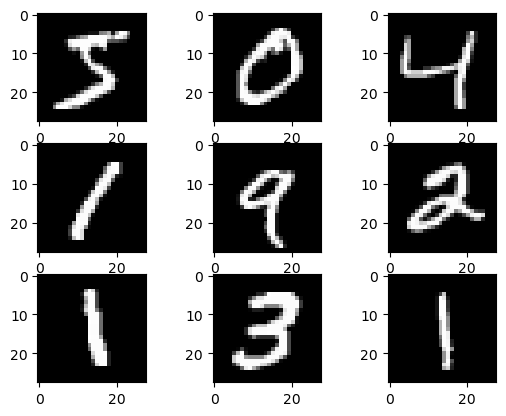

In [55]:
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')

Let's define a sequential model using Keras package:

In [56]:
 # Define model architecture
model = Sequential()
 
model.add(Convolution2D(64, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model.add(Convolution2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Convolution2D(64, kernel_size=(3,3), activation='relu'))
model.add(Convolution2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Convolution2D(128, kernel_size=(3,3), activation='relu'))
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.25))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,738 (741.16 KB)

 Trainable params: 189,738 (741.16 KB)

 Non-trainable params: 0 (0.00 B)

In the compile step, we chose:

- `Adaptive Moment Estimation (Adam)` is used as a loss function.
- loss function is `categorical_crossentropy`, which is another term for multiclass log loss. This is most suitable when working with a multinominal classification problem.
- metrics argument stores the measurement for evaluating model performance, and we are using `categorical_accuracy` metric.

In [58]:
# Compile model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['categorical_accuracy'])

In [59]:
# Fit model on training data
history= model.fit(X_train, y_train, 
          batch_size=32, epochs=10, verbose=1, validation_data=(X_test,y_test))
 

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - categorical_accuracy: 0.1450 - loss: 2.2706 - val_categorical_accuracy: 0.2800 - val_loss: 1.9686
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - categorical_accuracy: 0.3720 - loss: 1.7668 - val_categorical_accuracy: 0.6900 - val_loss: 1.0784
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - categorical_accuracy: 0.5550 - loss: 1.2962 - val_categorical_accuracy: 0.7800 - val_loss: 0.7311
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - categorical_accuracy: 0.6670 - loss: 1.0125 - val_categorical_accuracy: 0.9100 - val_loss: 0.4018
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - categorical_accuracy: 0.7250 - loss: 0.7610 - val_categorical_accuracy: 0.8900 - val_loss: 0.4111
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - categorical_accuracy: 0.7540 - loss: 0.7026 - val_categorical_accuracy: 0.9250 - val_loss: 0.3221
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - categorical_accuracy: 0.8180 - loss: 0.59

In [60]:
# Evaluate model on test data
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])
print("Test Error: %.2f%%" % (100-score[1]*100))

Test loss: 0.09102106839418411
Test accuracy: 0.9750000238418579
Test Error: 2.50%


### Visualize sample results

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


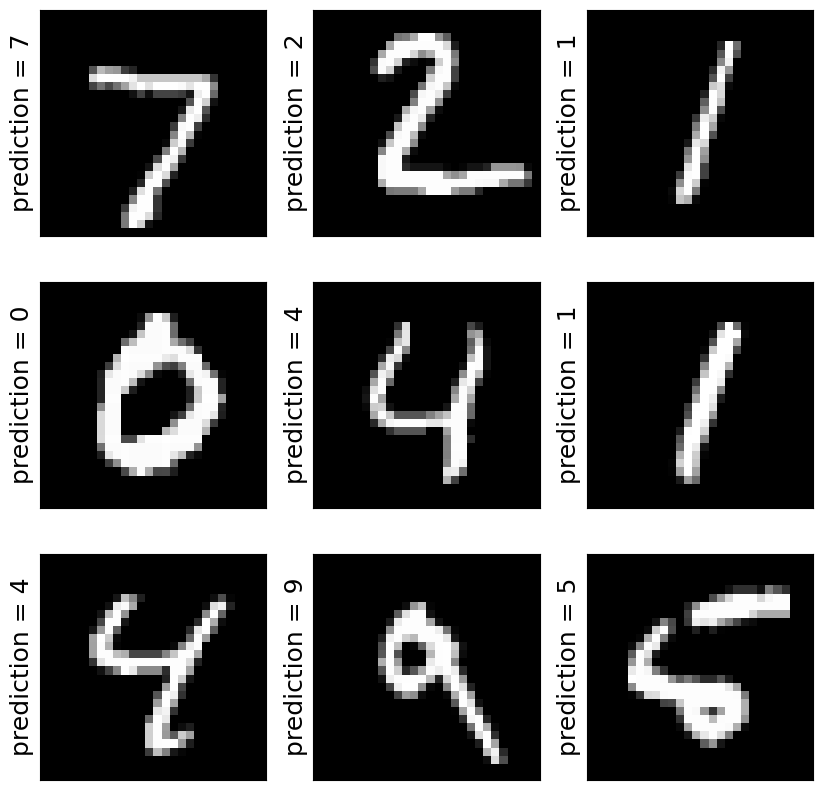

In [61]:
res = np.argmax(model.predict(X_test), axis=-1)
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.gca().get_xaxis().set_ticks([])
    plt.gca().get_yaxis().set_ticks([])
    plt.ylabel("prediction = %d" % res[i], fontsize=18)

### Install Graphviz 
- Use the instructions mentioned at https://graphviz.gitlab.io/download/
- if Path of Graphviz in not searched then you can add it, below is one example for MacOS.

In [65]:
# import os
# os.environ["PATH"] += os.pathsep + '/opt/homebrew/bin'

In [84]:
import shutil

plot_model(model, to_file='mnist_model.png')
try:
	SVG(model_to_dot(model).create(prog='dot', format='svg'))
except (OSError, FileNotFoundError) as exc:
	print(f"Graphviz 'dot' not found; skipping SVG render. Details: {exc}")
plot_model(model, to_file='mnist_model.png')
if shutil.which("dot") is None:
	print("Graphviz 'dot' is not available. Skipping SVG render.")
else:
	SVG(model_to_dot(model).create(prog='dot', format='svg'))

Let's plot the training history of the model, and two pieces of output show how our model improves with each epoch.

In [85]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


KeyError: 'categorical_accuracy'


### Question 

Modify the code in above code chunks to create a CNN model for Image Recognition (`model_cnn_2`) by adding two additional layers: 1) convolving layer (for a two-dimensional object) and, 2)  max pooling layer (to create downsampled version of data)  before layers added in model_cnn.
    Steps to be followed:
    1. Define Keras sequential model named model_cnn_2`.
    
    2. To add convolving layer use code `layer_conv_2d(filters = 484, kernel_size = c(7,7), activation = 'relu',input_shape = c(28,28,1))`.
    
    3. To add max pooling layer use code `layer_max_pooling_2d(pool_size = c(2, 2))`
    
    4. Now add fully connected layer to model using code:   
        layer_flatten() %>%
        layer_dense(units = 98, activation = 'relu') %>%
        layer_dense(units = 10, activation = 'softmax')
    5. Compile the model using 
        loss = 'categorical_crossentropy',
        optimizer = 'adam',
        metrics = 'accuracy'
    6. Fit the model using 
    fit(
          train, train_target,
          batch_size = 100,
          epochs = 10,
          verbose = 1,
          validation_data = validation_data = list(test, test_target)
        )
    7. Evaluate the model and compare its accuracy with model_cnn and comment on the accuracy of the model_cnn_2.

In [86]:
model_cnn_2 = Sequential()

# add a 2d convolution layer, pooling layer, and fully connected layers
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model_cnn_2.add(Conv2D(filters=484, kernel_size=(7,7), activation='relu', input_shape=(28,28,1)))
model_cnn_2.add(MaxPooling2D(pool_size=(2,2)))
model_cnn_2.add(Flatten())
model_cnn_2.add(Dense(units=98, activation='relu'))
model_cnn_2.add(Dense(units=10, activation='softmax'))

# define the compile step
model_cnn_2.compile(
loss = 'categorical_crossentropy',
optimizer = 'adam',
metrics = ['accuracy']
)

# fit the model
history = model_cnn_2.fit(
X_train, y_train,
batch_size = 100,
epochs = 5,
verbose = 1,
validation_data = (X_test, y_test)
)

# get the evaluation score
scores = model_cnn_2.evaluate(
X_test, y_test, verbose = 1
)
print(scores[1])

Epoch 1/5


/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.5780 - loss: 1.3448 - val_accuracy: 0.8000 - val_loss: 0.6326
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.8420 - loss: 0.5124 - val_accuracy: 0.8600 - val_loss: 0.4304
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9200 - loss: 0.3182 - val_accuracy: 0.9450 - val_loss: 0.2167
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.9440 - loss: 0.1913 - val_accuracy: 0.9500 - val_loss: 0.1389
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9660 - loss: 0.1237 - val_accuracy: 0.9550 - val_loss: 0.1312
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9550 - loss: 0.1312  
0.9549999833106995


In [87]:
# Evaluate model on test data
score = model_cnn_2.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])
print("Test Error: %.2f%%" % (100-score[1]*100))

Test loss: 0.1312199831008911
Test accuracy: 0.9549999833106995
Test Error: 4.50%


## Long Short-Term Memory Networks for Stock Forecasting

Unlike other models, Recurrent neural network (RNN) do not wait until the entire completion of forward pass. At a certain data point that represents a point in time is fed forward and evaluated by the activation function in a hidden layer unit. This activation function output is then used to calculate the next time-based data element with the next input. RNNs can therefore use what they just learned to determine how to process the next data point. This explains why they work well when analyzing data that includes a time component. However, RNNs do have one important limitation that makes them particularly unsuitable for time-series data. A recurrent element in the model only accounts for the time period that preceded it, and its signal can decay during backpropagation when there are a lot of hidden layers. Due to these two model characteristics, a node cannot apply the information it has learned over a long time horizon, even though it may be useful to it. The LSTM model solves this problem.

LSTM model is a special type of recurrent neural network (RNN). This model contains special characteristics that allows to reuse recent output as input. Here, we are going to use LSTM model for stock forecasting.

For our example, we will load 5 years of Facebook stock:

In [88]:
#!pip install  yfinance

In [90]:
import yfinance as yf
meta_data = yf.download('META', start='2014-01-01', end='2018-12-31')
meta_data.info()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2014-01-02 to 2018-12-28
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, META)   1257 non-null   float64
 1   (High, META)    1257 non-null   float64
 2   (Low, META)     1257 non-null   float64
 3   (Open, META)    1257 non-null   float64
 4   (Volume, META)  1257 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


We select just the closing prices from the data and store them in a new object by running the following code:

In [91]:
closing_prices =  meta_data["Close"]
closing_prices = pd.DataFrame(closing_prices)

We are adding here the actual data of future w.r.t data range used above to see whether the actual prices did fall nearby the predicted values.

In [92]:
meta_future = yf.download('META', start='2019-01-01', end='2019-12-31')
future_prices = meta_future["Close"]
future_prices = pd.DataFrame(future_prices)

[*********************100%***********************]  1 of 1 completed


Perform feature scaling to transform the data

In [93]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(0,1))
closing_prices_sc = sc.fit_transform(closing_prices)

In [94]:
closing_deltas = np.diff(np.log(np.vstack([closing_prices, future_prices])), axis=0)
closing_deltas = closing_deltas[~np.isnan(closing_deltas)]

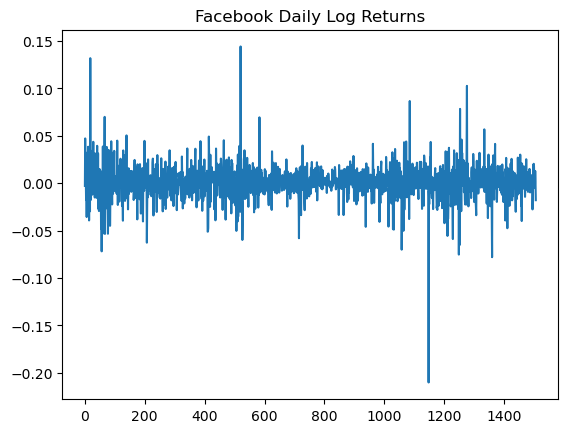

In [95]:
plt.plot(closing_deltas)
plt.title('Facebook Daily Log Returns')
plt.show()

LSTM model would use lagging historical data to predict actual data at a given point in time. However, in order to feed this data forward to an LSTM model, we must format the data so that a given number of columns contain all the lagging values and one column contains the target value. The following code chunk prepared the data so that LSTM model will look back 3 days to predict a given day:

In [96]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

train_gen = TimeseriesGenerator(
    closing_deltas,
    closing_deltas,
    length=3,
    sampling_rate=1,
    stride=1,
    start_index=0,
    end_index=1257,
    shuffle=False,
    reverse=False,
    batch_size=1
)

test_gen = TimeseriesGenerator(
    closing_deltas,
    closing_deltas,
    length=3,
    sampling_rate=1,
    stride=1,
    start_index=1258,
    end_index=1506,
    shuffle=False,
    reverse=False,
    batch_size=1
)

Let's get started with training our model. We follow the same steps as taken in the previous deep learning models with exception on adding LSTM layer with 4 units.

In [97]:

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

model_lstm = Sequential()
# add LSTM layer with number of units and input shape and also add one dense layer.
model_lstm.add(LSTM(units=4, input_shape = (3, 1)))
model_lstm.add(Dense(units=1))               
# compile
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
# train model
history = model_lstm.fit(
    train_gen,
    epochs=100,
    verbose=1
)

Epoch 1/100


/Users/ssehra/miniconda3/envs/mlcourse/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1255/1255 ━━━━━━━━━━━━━━━━━━━━ 2s 772us/step - loss: 3.7900e-04
Epoch 2/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step - loss: 3.7171e-04
Epoch 3/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 728us/step - loss: 3.6632e-04
Epoch 4/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 754us/step - loss: 3.6773e-04
Epoch 5/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step - loss: 3.6662e-04
Epoch 6/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step - loss: 3.7010e-04
Epoch 7/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - loss: 3.6542e-04
Epoch 8/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - loss: 3.6657e-04
Epoch 9/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 774us/step - loss: 3.6852e-04
Epoch 10/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 754us/step - loss: 3.6874e-04
Epoch 11/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 753us/step - loss: 3.6465e-04
Epoch 12/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step - loss: 3.6913e-04
Epoch 13/100
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step - loss: 3.6818e-04
Epoch 14/100
1255/12

In [100]:
# predictions and calculate the error rate.
def report_predictions_and_error(gen, steps, label):
    y_true = []
    for i in range(steps):
        _, y = gen[i]
        y_true.append(y)
    y_true = np.concatenate(y_true).squeeze()

    preds = model_lstm.predict(gen, steps=steps, verbose=0).squeeze()
    mae = np.mean(np.abs(preds - y_true))
    mse = np.mean((preds - y_true) ** 2)

    print(f"{label} predictions (first 10): {preds[:10]}")
    print(f"{label} MAE: {mae:.6f}")
    print(f"{label} MSE: {mse:.6f}")

report_predictions_and_error(test_gen, steps=200, label="Test")
report_predictions_and_error(train_gen, steps=1200, label="Train")
# warnings printed in the console can be ignored.

Test predictions (first 10): [0.00389805 0.00391979 0.00393462 0.00395615 0.00394718 0.00392236
 0.0039463  0.00394779 0.00394481 0.00396697]
Test MAE: 0.013452
Test MSE: 0.000340
Train predictions (first 10): [0.00390911 0.00392032 0.00396934 0.00395369 0.00399987 0.00393997
 0.00395343 0.00395345 0.00398357 0.00392696]
Train MAE: 0.012557
Train MSE: 0.000349


### When and When Not to Use Deep Learning

This worksheet only scratches the surface of deep learning. The increasing availability of pre-trained models on publicly available data, coupled with the outstanding performance of deep learning algorithms with complex tasks requiring tons of data, have made deep learning very attractive to organizations over the past few years. Despite the benefits of deep learning, it is not meant to solve all machine learning (ML) related issues. 


| Classical Machine Learning:                                                                                                                                                                                                                                                                                    | Deep Learning:                                                                                                                                                                                                                                                                                                     |
|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Interpretability and explainability are paramount  | Very high accuracy is a priority (and primes over straightforward interpretability and explainability) |
Smaller amounts of relatively simple data  | Large amounts of precisely labeled data |
Straightforward feature engineering  | Complex feature engineering |
Limited computational power and time, need for faster prototyping and operationalization| Powerful compute resources available (GPU acceleration) |
Need for varied algorithm choices | Augmentation and other transformations of the initial dataset will be necessary |
Accuracy of test dataset results is acceptable  |    

### References:

[1]. https://hastie.su.domains/ISLR2/ISLRv2_website.pdf

[2]. https://www.manning.com/books/deep-learning-with-r

[3]. https://bradleyboehmke.github.io/HOML/

[4]. https://www.packtpub.com/product/hands-on-deep-learning-with-r/9781788996839

